In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error as mse
from sklearn.neighbors import KernelDensity

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.optimizers import *
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [2]:
os.chdir('/users/PES0841/yizicheng/LSTM/AMOCindex/AllD_data')

In [3]:
print(os.getcwd())

/users/PES0841/yizicheng/LSTM/AMOCindex/AllD_data


In [4]:
AMOC_Obs = pd.read_csv("dtdata_AMOC_Obs.csv", usecols=[1, 2])
AMOC_Ensemble = pd.read_csv("dtdata_AMOC_Ensemble.csv", usecols=list(range(1, 30)))

AMOCindex_Obs = pd.read_csv("dtdata_AMOCindex_Obs.csv", usecols=[1, 2])
AMOCindex_Ensemble = pd.read_csv("dtdata_AMOCindex_Ensemble.csv", usecols=list(range(1, 30)))

In [5]:
class Scaler:

    def __init__(self, *args):
        data_min = np.array([])
        data_max = np.array([])

        for i in args:
            a = np.array(i.min())
            b = np.array(i.max())
            data_min = np.append(data_min, a)
            data_max = np.append(data_max, b)

        self.min = min(data_min)
        self.max = max(data_max)

    def transform(self, X):
        return (X - self.min) / (self.max - self.min)

#     def inverse_transform(self, X):
#         return X * (self.max - self.min) + self.min
    def inverse_transform(self, X):
        return X * (self.max - self.min)

AMOC_scaler = Scaler(AMOC_Obs.iloc[:,1], AMOC_Ensemble.iloc[:, range(1,29)])
AMOC_Ensemble_std = pd.concat([AMOC_Ensemble.iloc[:, 0], AMOC_scaler.transform(AMOC_Ensemble.iloc[:, list(range(1, 29))])], axis=1)
AMOC_Obs_std = pd.concat([AMOC_Obs.iloc[:, 0], AMOC_scaler.transform(pd.DataFrame(AMOC_Obs.iloc[:, 1]))], axis=1)

AMOCindex_scaler = Scaler(AMOCindex_Obs.iloc[:, 1], AMOCindex_Ensemble.iloc[:, range(1, 29)])
AMOCindex_Ensemble_std = pd.concat([AMOCindex_Ensemble.iloc[:, 0], AMOCindex_scaler.transform(AMOCindex_Ensemble.iloc[:, list(range(1, 29))])], axis=1)
AMOCindex_Obs_std = pd.concat([AMOCindex_Obs.iloc[:, 0], AMOCindex_scaler.transform(pd.DataFrame(AMOCindex_Obs.iloc[:, 1]))], axis=1)

In [6]:
Obs_length = len(AMOC_Obs_std)

naindex = AMOC_Obs_std[pd.isna(AMOC_Obs_std.loc[:, 'Obs'])].index.to_list()

In [7]:
def generator(seq_cols, df_1 = AMOC_Ensemble_std, df_2 = AMOCindex_Ensemble_std, num_select=6000):
    AMOC = np.array(df_1.iloc[:, 1:])
    AMOC_index = np.array(df_2.iloc[:, 1:])
    seq_length = AMOC.shape[0]

    index = [np.random.randint(0, seq_length - Obs_length) for i in range(num_select)]

    sequence_input_1 = []
    sequence_input_2 = []
    sequence_input_3 = []
    sequence_target = []

    for i, id in enumerate(index):
        sdata_AMOC_1 = np.copy(AMOC[id:(id + Obs_length), :])
        sdata_AMOC_2 = np.delete(sdata_AMOC_1, naindex, axis=0)
        mean = sdata_AMOC_2.mean(axis=0)
        sdata_AMOC_1 = sdata_AMOC_1 - mean
        sdata_AMOC_2 = sdata_AMOC_2 - mean
        a = np.array(range(Obs_length))
        p = np.poly1d(np.polyfit(a.repeat(seq_cols), sdata_AMOC_1.flatten(), 2))
        y = np.reshape(p(range(Obs_length)), (Obs_length, 1))
        
        sdata_AMOCindex = np.copy(AMOC_index[id:(id + Obs_length), :])
        mean_AMOCindex = sdata_AMOCindex.mean(axis=0)
        sdata_AMOCindex = sdata_AMOCindex - mean_AMOCindex
        for j in range(seq_cols):
            sequence_input_1.append(sdata_AMOC_2[:6, j].reshape((6, 1)))
            sequence_input_2.append(sdata_AMOC_2[6:, j].reshape((len(sdata_AMOC_2) - 6, 1)))
            sequence_input_3.append(sdata_AMOCindex[:, j].reshape(Obs_length, 1))
            sequence_target.append(y)

    sequence_input_1 = np.array(sequence_input_1)
    sequence_input_2 = np.array(sequence_input_2)
    sequence_input_3 = np.array(sequence_input_3)
    sequence_target = np.array(sequence_target)
    # should use np.stack() here, but this works too.

    return sequence_input_1, sequence_input_2, sequence_input_3, sequence_target, index

np.random.seed(1)
sequence_input_1, sequence_input_2, sequence_input_3, sequence_target, index = generator(28)

In [9]:
### TRAIN TEST SPLIT ###
train_size = 0.8

sequence_input_1_train = sequence_input_1[:int(len(sequence_input_1)*train_size)]
sequence_input_1_test = sequence_input_1[int(len(sequence_input_1)*train_size):]

sequence_input_2_train = sequence_input_2[:int(len(sequence_input_2)*train_size)]
sequence_input_2_test = sequence_input_2[int(len(sequence_input_2)*train_size):]

sequence_input_3_train = sequence_input_3[:int(len(sequence_input_3)*train_size)]
sequence_input_3_test = sequence_input_3[int(len(sequence_input_3)*train_size):]

sequence_target_train = sequence_target[:int(len(sequence_target)*train_size)]
sequence_target_test = sequence_target[int(len(sequence_target)*train_size):]

In [10]:
### UTILITY FUNCTIONS FOR VAE CREATION ###

latent_dim = 5

def set_seed(seed):
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)

def sampling(args):
    z_mean, z_log_sigma = args
    batch_size = tf.shape(z_mean)[0]
    epsilon = K.random_normal(shape=(batch_size, latent_dim, 8), mean=0., stddev=1.)

    return z_mean + K.exp(0.5 * z_log_sigma) * epsilon

def vae_loss(original, out, z_mean, z_log_sigma, tuning1=1.0, tuning2=1.0, tuning3=1.0, tuning4=1.0):
    diff1 = out[:, 1:, :] - out[:, :(-1), :]
    diff2 = diff1[:, 1:, :] - diff1[:, :(-1), :]

    smoothness1 = K.mean(K.square(diff1)) * tuning1
    smoothness2 = K.mean(K.square(diff2)) * tuning2
    reconstruction = K.mean(K.square(original - out)) * Obs_length * tuning3
    kl = -0.5 * K.mean(1 + z_log_sigma - K.square(z_mean) - K.exp(z_log_sigma)) * tuning4

    return smoothness1 + smoothness2 + reconstruction + kl

In [11]:
def Conv1DTranspose(input_tensor, filters=8, kernel_size=60, strides=4, padding='same', activation='relu'):
    """
        input_tensor: tensor, with the shape (batch_size, time_steps, dims)
        filters: int, output dimension, i.e. the output tensor will have the shape of (batch_size, time_steps, filters)
        kernel_size: int, size of the convolution kernel
        strides: int, convolution step size
        padding: 'same' | 'valid'
    """
    x = Lambda(lambda x: K.expand_dims(x, axis=2))(input_tensor)
    x = Conv2DTranspose(filters=filters, kernel_size=(kernel_size, 1), strides=(strides, 1), padding=padding, activation=activation)(x)
    x = Lambda(lambda x: K.squeeze(x, axis=2))(x)
    return x

In [12]:
def get_model():
    set_seed(2)
    #latent_dim specified by conv1D output shape

    ### encoder ###

    inp_1 = Input(shape=(6, 1))
    inp_2 = Input(shape=(173, 1))
    inp_3 = Input(shape=(Obs_length, 1))
    target = Input(shape=(Obs_length, 1))

    inp_AMOC = Concatenate(axis=1)([inp_1] + [inp_2])

    enc_AMOC_1 = Conv1D(filters=8, strides=4, kernel_size=60, activation='relu', padding='same', input_shape=(inp_AMOC.shape[1:]))(
        inp_AMOC)
    enc_AMOC_2 = Conv1D(filters=8, strides=3, kernel_size=60, activation='relu', padding='same')(enc_AMOC_1)
    enc_AMOC_3 = Conv1D(filters=8, strides=3, kernel_size=60, activation='relu', padding='same')(enc_AMOC_2)

    enc_AMOCindex_1 = Conv1D(filters=8, strides=7, kernel_size=60, activation='relu', padding='same', input_shape=(inp_3.shape[1:]))(
        inp_3)
    enc_AMOCindex_2 = Conv1D(filters=8, strides=4, kernel_size=60, activation='relu', padding='same')(enc_AMOCindex_1)
    enc_AMOCindex_3 = Conv1D(filters=8, strides=4, kernel_size=60, activation='relu', padding='same')(enc_AMOCindex_2)
    enc_AMOCindex_4 = Conv1D(filters=8, strides=3, kernel_size=60, activation='relu', padding='same')(enc_AMOCindex_3)

    enc_out = Concatenate(axis=2)([enc_AMOC_3] + [enc_AMOCindex_4])

    z_mean = Dense(8)(enc_out)
    z_log_sigma = Dense(8)(enc_out)

    encoder = Model([inp_1, inp_2, inp_3], [z_mean, z_log_sigma])

    ### decoder ###

    inp_z = Input(shape=(latent_dim, 8))

    conv_1 = Conv1DTranspose(inp_z, filters=8, kernel_size=30, strides=7, padding='same', activation='relu')
    conv_2 = Conv1DTranspose(conv_1, filters=8, kernel_size=60, strides=4, padding='same', activation='relu')
    conv_3 = Conv1DTranspose(conv_2, filters=8, kernel_size=60, strides=4, padding='same', activation='relu')
    conv_4 = Conv1DTranspose(conv_3, filters=8, kernel_size=60, strides=3, padding='same', activation='linear')

    out = Dense(1)(conv_4)

    decoder = Model([inp_z], [out])

    ### encoder + decoder ###

    z_mean, z_log_sigma = encoder([inp_1, inp_2, inp_3])
    z = Lambda(sampling)([z_mean, z_log_sigma])
    pred = decoder([z])

    vae = Model([inp_1, inp_2, inp_3, target], pred)
    vae.add_loss(vae_loss(target, pred, z_mean, z_log_sigma, tuning1=0, tuning2=0, tuning3=1.0, tuning4=4.5))
    vae.compile(loss=None, optimizer=Adam(lr=1e-3))

    return vae, encoder, decoder

# logdir="logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# es = [
#     EarlyStopping(patience=10, verbose=1, min_delta=0.001, monitor='val_loss', mode='auto', restore_best_weights=True),
#     ModelCheckpoint(filepath='best_model.hdf5', save_freq='epoch', save_best_only=True),
#     keras.callbacks.TensorBoard(log_dir=logdir)]

In [13]:
es = [
    EarlyStopping(patience=10, verbose=1, min_delta=0.001, monitor='val_loss', mode='auto', restore_best_weights=True),
    ModelCheckpoint(filepath='best_model.hdf5', save_freq='epoch', save_best_only=True)]
vae, enc, dec = get_model()
vae.fit([sequence_input_1_train, sequence_input_2_train, sequence_input_3_train, sequence_target_train], batch_size=128, epochs=150, validation_split=0.2, shuffle=False, callbacks=es)

Train on 107520 samples, validate on 26880 samples
Epoch 1/150
107520/107520 [==============================] - 40s 369us/sample - loss: 7.4386 - val_loss: 2.7742
Epoch 2/150
107520/107520 [==============================] - 38s 351us/sample - loss: 2.3303 - val_loss: 2.0318
Epoch 3/150
107520/107520 [==============================] - 38s 351us/sample - loss: 1.8907 - val_loss: 3.9508
Epoch 4/150
107520/107520 [==============================] - 38s 353us/sample - loss: 1.6174 - val_loss: 2.2120
Epoch 5/150
107520/107520 [==============================] - 38s 352us/sample - loss: 1.7007 - val_loss: 4.1266
Epoch 6/150
107520/107520 [==============================] - 38s 352us/sample - loss: 1.5129 - val_loss: 1.4793
Epoch 7/150
107520/107520 [==============================] - 38s 357us/sample - loss: 1.4478 - val_loss: 3.2263
Epoch 8/150
107520/107520 [==============================] - 39s 359us/sample - loss: 1.3476 - val_loss: 1.2979
Epoch 9/150
107520/107520 [==========================

In [14]:
file = 'model_2_output/'

In [15]:
### pred Obs ###
Obs = np.array(AMOC_Obs_std.loc[:, 'Obs'])
Obs = Obs[~np.isnan(Obs)]
mean = np.mean(Obs)
Obs = Obs - mean
Obs_inp_1 = Obs[:6].reshape((1, -1, 1))
Obs_inp_2 = Obs[6:].reshape((1, -1, 1))
Obs_inp_3 = np.array(AMOCindex_Obs_std.loc[:, 'Obs']).reshape((1, -1, 1))
mean = np.mean(Obs_inp_3)
Obs_inp_3 = Obs_inp_3 - mean

Obs_pred = np.zeros((1000, Obs_length, 1))

for i in range(1000):
    Obs_pred[i, :, :] = AMOC_scaler.inverse_transform(vae.predict([Obs_inp_1, Obs_inp_2, Obs_inp_3, np.zeros((1, Obs_length, 1))]))

In [16]:
np.save(file + 'Obs_pred.npy', Obs_pred)

In [ ]:
# Obs_pred = np.load(file + 'Obs_pred.npy')

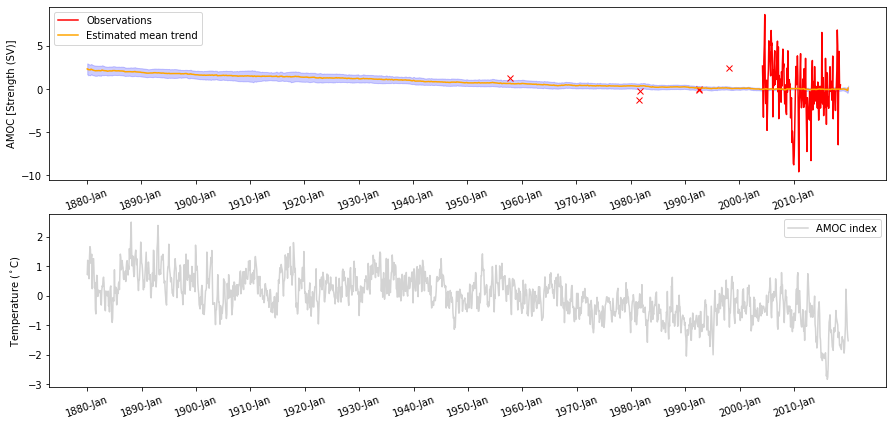

In [17]:
### Plot CI for 1000 trials Obs
Obs_pred_1000 = np.squeeze(Obs_pred)
mean = np.mean(Obs_pred_1000, axis=0)
std = np.std(Obs_pred_1000, axis=0)

### confidence interval ###
x = np.linspace(1, Obs_length, Obs_length)
ci = 1.96 * std

a = np.array(AMOC_Obs['Obs'])
idx = np.array(np.where(~np.isnan(a)))
a_mean = np.mean(a[np.where(~np.isnan(a))])
a = a - a_mean

b = np.array(AMOCindex_Obs['Obs'])
b_mean = np.mean(b)
b = b - b_mean

foo = plt.figure(figsize=(15, 7))
plt.subplot(2, 1, 1)
for i in range(6):
    plt.plot(idx[:, i], a[np.where(~np.isnan(a))][i], c='red', marker='x')
plt.plot(idx[0, 6:], a[np.where(~np.isnan(a))][6:],c='red', label='Observations')
plt.plot(x, mean, c='orange', label='Estimated mean trend')
plt.fill_between(x, (mean-ci), (mean+ci), color='b', alpha=.2)
xlocs=np.arange(0, Obs_length, step=120)
plt.xticks(xlocs, AMOC_Obs['Time_Obs'][xlocs], rotation=20)
plt.ylabel(r'AMOC [Strength (SV)]')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(b, c='lightgray', label='AMOC index')
plt.xticks(xlocs, AMOC_Obs['Time_Obs'][xlocs], rotation=20)
plt.ylabel('Temperature ($^\circ$C)')
plt.legend()

foo.savefig(file + 'Obs_pred_para.png', bbox_inches='tight')

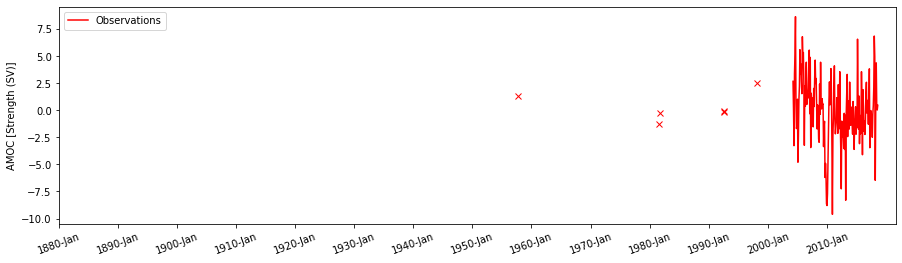

In [18]:
# # Obs plot####

a = np.array(AMOC_Obs['Obs'])
idx = np.array(np.where(~np.isnan(a)))
a_mean = np.mean(a[np.where(~np.isnan(a))])
a = a - a_mean
xlocs=np.arange(0, Obs_length, step=120)

foo = plt.figure(figsize=(15, 4))
for i in range(6):
    plt.plot(idx[:, i], a[np.where(~np.isnan(a))][i], c='red', marker='x')
plt.plot(idx[0, 6:], a[np.where(~np.isnan(a))][6:],c='red', label='Observations')
plt.xticks(xlocs, AMOC_Obs['Time_Obs'][xlocs], rotation=20)
plt.ylabel(r'AMOC [Strength (SV)]')
plt.legend()

foo.savefig(file + 'Obs.png', bbox_inches='tight')

In [ ]:
# Density plot
# Obs_pred = np.load(file + 'Obs_pred.npy')

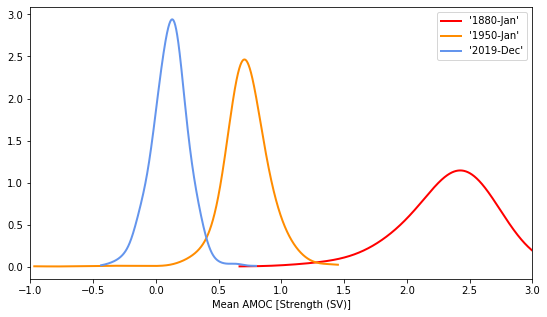

In [46]:
point = [0, 840, 1679]

colors = ['red', 'darkorange', 'cornflowerblue']

bandwidth = [0.2, 0.1, 0.05]

fig, ax = plt.subplots(figsize=(9, 5))

for a, color, w in zip(point, colors, bandwidth):
    X_inp = Obs_pred[:, a, 0][:, np.newaxis]
    kde = KernelDensity(kernel='gaussian', bandwidth=w).fit(X_inp)
    X_plot = np.linspace(np.min(X_inp), np.max(X_inp), 5000)[:, np.newaxis]
    log_dens = kde.score_samples(X_plot)
    position = AMOC_Obs['Time_Obs'][a]
    ax.plot(X_plot[:, 0], np.exp(log_dens), color=color, lw=2,
            linestyle='-', label="'{0}'".format(position))

ax.legend(loc='upper right')
ax.set_xlim(-1, 3.0)
ax.set_xlabel(r'Mean AMOC [Strength (SV)]')
# ax.set_ylim(0.78, 0.8)

plt.show()

fig.savefig(file + 'density.png', bbox_inches='tight')

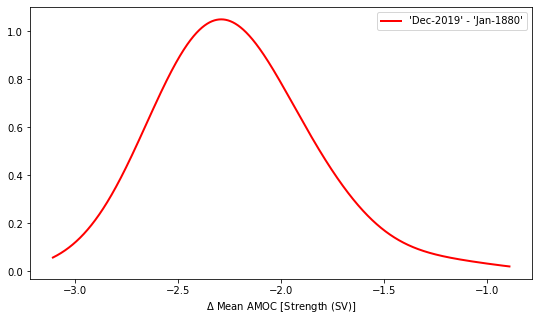

In [48]:
X_inp = Obs_pred[:, 1679, 0][:, np.newaxis] - Obs_pred[:, 0, 0][:, np.newaxis] 
kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(X_inp)
X_plot = np.linspace(np.min(X_inp), np.max(X_inp), 5000)[:, np.newaxis]
log_dens = kde.score_samples(X_plot)

foo = plt.figure(figsize=(9, 5))
plt.plot(X_plot[:, 0], np.exp(log_dens), color='red', lw=2,
            linestyle='-', label="'Dec-2019' - 'Jan-1880'")
plt.legend(loc='upper right')
plt.xlabel(r'$\Delta$ Mean AMOC [Strength (SV)]')
# plt.xlim(-4, 1)
plt.show()

foo.savefig(file + 'density_diff.png', bbox_inches='tight')

In [61]:
X_inp[X_inp < -1.0].shape

(997,)

In [ ]:
# 997/1000

In [19]:
#Pred testing data set
sequence_test_pred = np.zeros((1000, 33600, Obs_length, 1))

for i in range(1000):
    sequence_test_pred[i, :, :, :] = AMOC_scaler.inverse_transform(vae.predict([sequence_input_1_test, sequence_input_2_test, sequence_input_3_test, np.zeros((33600, Obs_length, 1))]))

In [20]:
sequence_test_pred_0 = sequence_test_pred[:, 0, :, :]
sequence_test_pred_1000 = sequence_test_pred[:, 1000, :, :]
sequence_test_pred_4000 = sequence_test_pred[:, 4000, :, :]
sequence_test_pred_8000 = sequence_test_pred[:, 8000, :, :]
sequence_test_pred_10000 = sequence_test_pred[:, 10000, :, :]

In [21]:
np.save(file + 'sequence_test_pred_0.npy', sequence_test_pred_0)
np.save(file + 'sequence_test_pred_1000.npy', sequence_test_pred_1000)
np.save(file + 'sequence_test_pred_4000.npy', sequence_test_pred_4000)
np.save(file + 'sequence_test_pred_8000.npy', sequence_test_pred_8000)
np.save(file + 'sequence_test_pred_10000.npy', sequence_test_pred_10000)

In [22]:
# sequence_test_pred_0 = np.load(file + 'sequence_test_pred_0.npy')
# sequence_test_pred_1000 = np.load(file + 'sequence_test_pred_1000.npy')
# sequence_test_pred_4000 = np.load(file + 'sequence_test_pred_4000.npy')
# sequence_test_pred_8000 = np.load(file + 'sequence_test_pred_8000.npy')
# sequence_test_pred_10000 = np.load(file + 'sequence_test_pred_10000.npy')

# sequence_test_pred = np.zeros((1000, 33600, Obs_length, 1))
# sequence_test_pred[:, 0, :, :] = sequence_test_pred_0
# sequence_test_pred[:, 1000, :, :] = sequence_test_pred_1000
# sequence_test_pred[:, 4000, :, :] = sequence_test_pred_4000
# sequence_test_pred[:, 8000, :, :] = sequence_test_pred_8000
# sequence_test_pred[:, 10000, :, :] = sequence_test_pred_10000

In [ ]:
# np.save(file + 'sequence_test_pred.npy',sequence_test_pred)

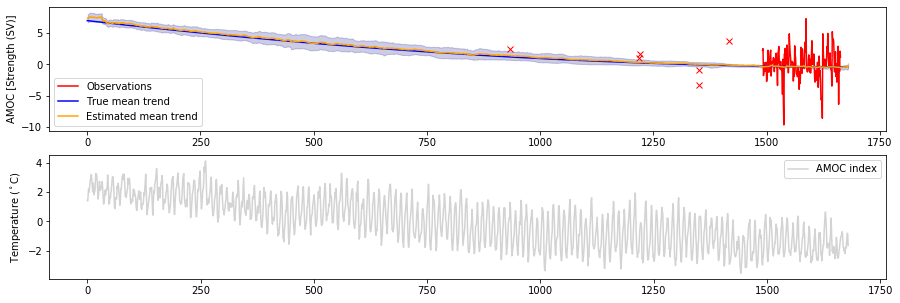

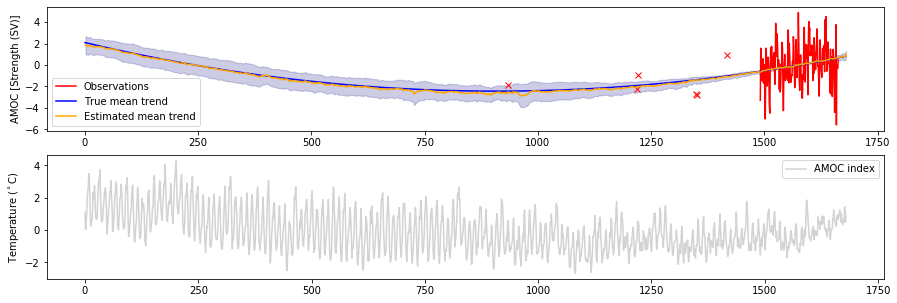

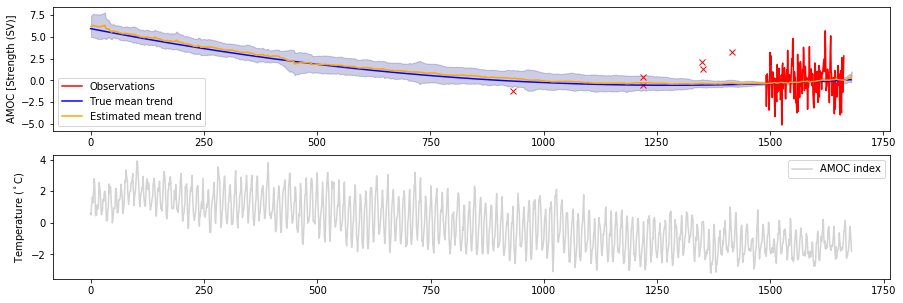

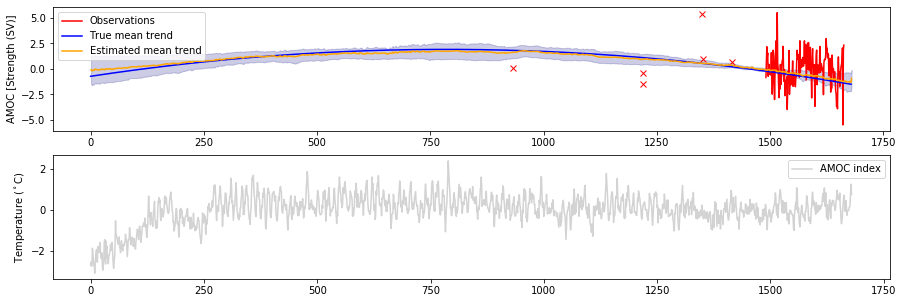

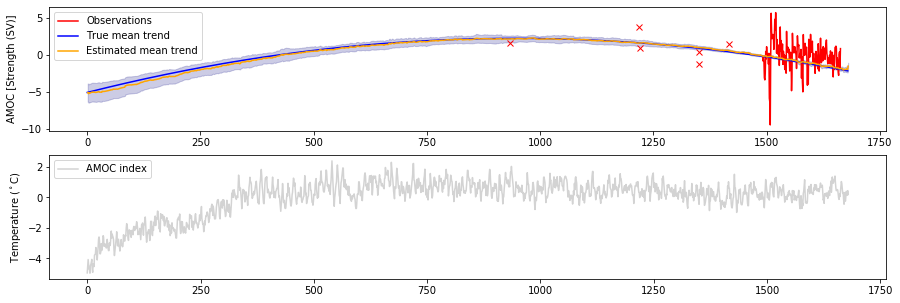

In [24]:
# Get some example for testing data set###

l = [0, 1000, 4000, 8000, 10000]

for i, a in enumerate(l):
    sequence_test_pred_1000 = np.squeeze(sequence_test_pred[:, a, :, :])
    mean = np.mean(sequence_test_pred_1000, axis=0)
    std = np.std(sequence_test_pred_1000, axis=0)

    ### confidence interval ###
    x = np.linspace(1, Obs_length, Obs_length)
    ci = 1.96 * std

    Obs = np.array(AMOC_Obs['Obs'])
    idx = np.array(np.where(~np.isnan(Obs)))

    foo = plt.figure(figsize=(15, 5))
    plt.subplot(2, 1, 1)
    for j in range(6):
        plt.plot(idx[:, j], AMOC_scaler.inverse_transform(sequence_input_1_test[a, j, :]), c='red', marker='x')
    plt.plot(idx[0, 6:], AMOC_scaler.inverse_transform(sequence_input_2_test[a, :, :]), c='red', label='Observations')
    plt.plot(AMOC_scaler.inverse_transform(sequence_target_test[a, :, :]), c='blue', label='True mean trend')
    plt.plot(x,mean,c='orange', label='Estimated mean trend')
    plt.fill_between(x, (mean-ci), (mean+ci), color='navy', alpha=.2)
    # for i in range(1000):
    #     plt.plot(sequence_test_pred_1000[i, :], linewidth=0.01, c='bisque')
    plt.ylabel(r'AMOC [Strength (SV)]')
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(AMOCindex_scaler.inverse_transform(sequence_input_3_test[a, :, :]), c='lightgray', label='AMOC index')
    plt.ylabel('Temperature ($^\circ$C)')
    plt.legend()

    foo.savefig(file + str(a) +'.png', bbox_inches='tight')

In [25]:
# ### Get emp_prob ###
# sequence_test_pred = np.load('sequence_test_pred_100.npy')

### confidence interval ###
emp_prob = np.zeros((33600, ))

for i in range(33600):
    sequence_test_pred_1000 = np.squeeze(sequence_test_pred[:, i, :, :])
    mean = np.mean(sequence_test_pred_1000, axis=0)
    std = np.std(sequence_test_pred_1000, axis=0)
    ci = 1.96 * std
    lower = mean - ci
    upper = mean + ci
    count = 0
    for j in range(Obs_length):
        a = AMOC_scaler.inverse_transform(sequence_target_test[i, j, :])
        if ((a >= lower[j]) and (a <= upper[j])):
            count = count + 1
    emp_prob[i] = count/Obs_length

In [26]:
np.save(file + 'emp_prob.npy', emp_prob)

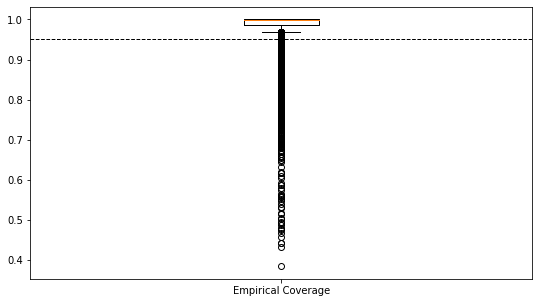

In [27]:
foo = plt.figure(figsize=(9, 5)) 
plt.boxplot(emp_prob, labels=['Empirical Coverage'])
plt.axhline(y=0.95, color='black', linestyle='--', lw=1)
foo.savefig(file + 'emp_prob.png', bbox_inches='tight')

In [28]:
quartiles = np.percentile(emp_prob, [0, 25, 50, 75, 100])
quartiles

array([0.38452381, 0.98690476, 0.99761905, 1.        , 1.        ])

In [29]:
# ### emp_prob_sub ###

# # sequence_test_pred = np.load('sequence_test_pred_450.npy')

# emp_prob_sub = np.zeros((33600, ))
# l = 50

# for i in range(33600):
#     sequence_test_pred_1000 = np.squeeze(sequence_test_pred[:, i, :, :])
#     mean = np.mean(sequence_test_pred_1000, axis=0)
#     std = np.std(sequence_test_pred_1000, axis=0)
#     ci = 1.96 * std
#     lower = mean - ci
#     upper = mean + ci
#     count = 0
#     r = list(range(l))+list(range(Obs_length-l,Obs_length))
#     for j, k in enumerate(r):
#         a = AMOC_scaler.inverse_transform(sequence_target_test[i, k, :])
#         if ((a >= lower[k]) and (a <= upper[k])):
#             count = count + 1
#     emp_prob_sub[i] = count/(2*l)

In [30]:
# np.save(file + 'emp_prob_sub.npy', emp_prob_sub)

In [31]:
### calculate bias ###
# sequence_test_pred = np.load('sequence_test_pred_450.npy')

sequence_test_bias = np.zeros((33600, Obs_length))

for i in range(33600):
    sequence_test_pred_1000 = np.squeeze(sequence_test_pred[:, i, :, :])
    mean = np.mean(sequence_test_pred_1000, axis=0)
    bias = np.squeeze(AMOC_scaler.inverse_transform(sequence_target_test[i, :, :])) - mean
    sequence_test_bias[i, :] = bias

In [32]:
np.save(file + 'sequence_test_bias.npy', sequence_test_bias)

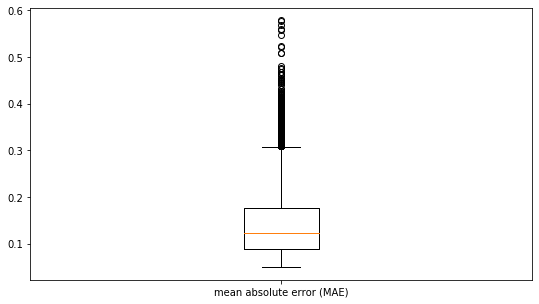

In [33]:
bias = np.absolute(sequence_test_bias)
box_bias = np.sum(bias, axis=1)/Obs_length
foo = plt.figure(figsize=(9, 5)) 
plt.boxplot(box_bias, labels=['mean absolute error (MAE)'])
foo.savefig(file + 'mean_absolute_error_bias.png', bbox_inches='tight')

In [34]:
quartiles = np.percentile(box_bias, [0, 25, 50, 75, 100])
quartiles

array([0.04873803, 0.08888688, 0.12219282, 0.17661351, 0.57884109])

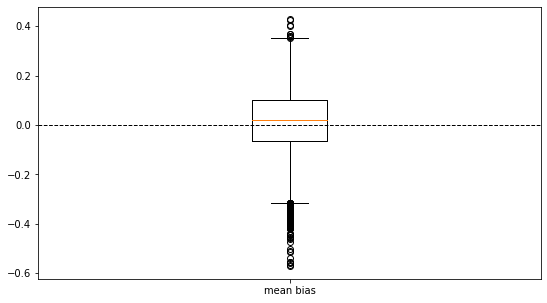

In [35]:
box_bias = np.sum(sequence_test_bias, axis=1)/Obs_length
foo = plt.figure(figsize=(9, 5)) 
plt.boxplot(box_bias, labels=['mean bias'])
plt.axhline(y=0, color='black', linestyle='--', lw=1)
foo.savefig(file + 'mean_bias.png', bbox_inches='tight')

In [36]:
quartiles = np.percentile(box_bias, [0, 25, 50, 75, 100])
quartiles

array([-0.57289019, -0.06575952,  0.02184209,  0.10095365,  0.4273815 ])